In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    f1_score
)

from xgboost import XGBClassifier

In [3]:
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [4]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target_original'] = data.target

df['target'] = 1 - df['target_original']

df['target_name'] = df['target'].map({
    0: 'benign',
    1: 'malignant'
})

print('데이터 크기 (행, 열):', df.shape)

데이터 크기 (행, 열): (569, 33)


In [5]:
df[['target_original', 'target', 'target_name']].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [6]:
df['target_name'].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [7]:
X = df.drop(columns=['target_original', 'target', 'target_name'])

y = df['target']

print('X의 열 개수:', X.shape[1])
print('정답 관련 컬럼이 X에 있나요?',
      any(col in X.columns for col in ['target_original', 'target', 'target_name']))

X의 열 개수: 30
정답 관련 컬럼이 X에 있나요? False


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('학습용 데이터 개수:', X_train.shape[0])
print('평가용 데이터 개수:', X_test.shape[0])

학습용 데이터 개수: 455
평가용 데이터 개수: 114


In [9]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

print('예측 완료! 예측한 데이터 개수:', len(y_pred))
print('예측값 예시 (앞 10개):', y_pred[:10])
print('malignant 확률 예시 (앞 5개):', y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수: 114
예측값 예시 (앞 10개): [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개): [0.001 1.    0.04  0.993 0.017]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print('accuracy:', accuracy)
print(f'즉, 전체의 약 {accuracy*100:.1f}%를 맞혔습니다.')

accuracy: 0.9736842105263158
즉, 전체의 약 97.4%를 맞혔습니다.


In [11]:
class_names = ['benign', 'malignant']

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

[[72  0]
 [ 3 39]]


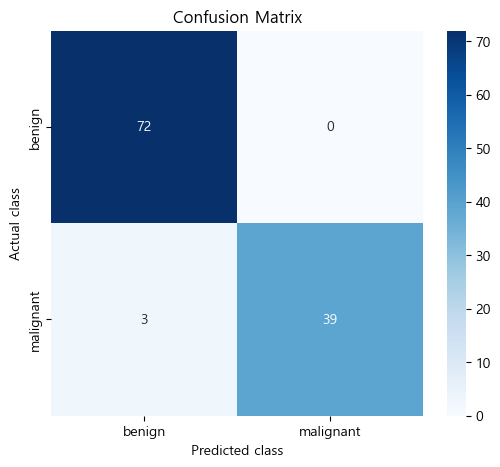

In [12]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion Matrix')
plt.show()

In [13]:
X_test_reset = X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)

result_df = X_test_reset.copy()

result_df['y_true'] = y_test_reset
result_df['y_pred'] = y_pred

result_df['malignant_probability'] = y_pred_proba

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [15]:
result_df['y_true_name'] = result_df['y_true'].map({0: 'benign', 1: 'malignant'})
result_df['y_pred_name'] = result_df['y_pred'].map({0: 'benign', 1: 'malignant'})

result_df['is_correct'] = result_df['y_true'] == result_df['y_pred']

result_df[['y_true', 'y_pred', 'y_true_name', 'y_pred_name', 'malignant_probability', 'is_correct']].head()

,y_true,y_pred,y_true_name,y_pred_name,malignant_probability,is_correct
0,0,0,benign,benign,0.001136,True
1,1,1,malignant,malignant,0.999783,True
2,0,0,benign,benign,0.039927,True
3,1,1,malignant,malignant,0.993436,True
4,0,0,benign,benign,0.016957,True


In [16]:
wrong_df = result_df[result_df['is_correct'] == False]

print('틀린 예측 개수:', len(wrong_df))

if len(wrong_df) == 0:
    print('이번 test split에서는 틀린 예측이 발생하지 않았습니다.')
else:
    important_columns = [
        'y_true_name',
        'y_pred_name',
        'malignant_probability',
        'mean radius',
        'mean perimeter',
        'mean area',
        'worst radius',
        'worst perimeter',
        'worst area',
        'worst concave points'
    ]
    
    available_colums = [col for col in important_columns if col in wrong_df.columns]
    
    display(wrong_df[available_colums].round(3))

틀린 예측 개수: 3


,y_true_name,y_pred_name,malignant_probability,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area,worst concave points
16,malignant,benign,0.003,13.80,90.43,584.1,16.57,110.3,812.4,0.138
69,malignant,benign,0.377,12.45,82.57,477.1,15.47,103.4,741.6,0.174
112,malignant,benign,0.261,15.12,98.78,716.6,17.77,117.7,989.5,0.125


In [17]:
# False Negative(FN): 실제 악성이지만 양성으로 예측
false_negative_df = result_df[
    (result_df['y_true'] == 1) &
    (result_df['y_pred'] == 0)
]

print('False Negative 개수:', len(false_negative_df))

if len(false_negative_df) == 0:
    print('이번 test split에서는 false negative가 발생하지 않았습니다.')
else:
    display(false_negative_df[['y_true_name', 'y_pred_name']])

False Negative 개수: 3


,y_true_name,y_pred_name
16,malignant,benign
69,malignant,benign
112,malignant,benign


In [18]:
# False Positive(FP): 실제 양성이지만 악성으로 예측
false_positive_df = result_df[
    (result_df['y_true'] == 0) &
    (result_df['y_pred'] == 1)
]

print('False Positive 개수:', len(false_positive_df))

if len(false_positive_df) == 0:
    print('이번 test split에서는 false positive가 발생하지 않았습니다.')
else:
    display(false_positive_df[['y_true_name', 'y_pred_name']])

False Positive 개수: 0
이번 test split에서는 false positive가 발생하지 않았습니다.


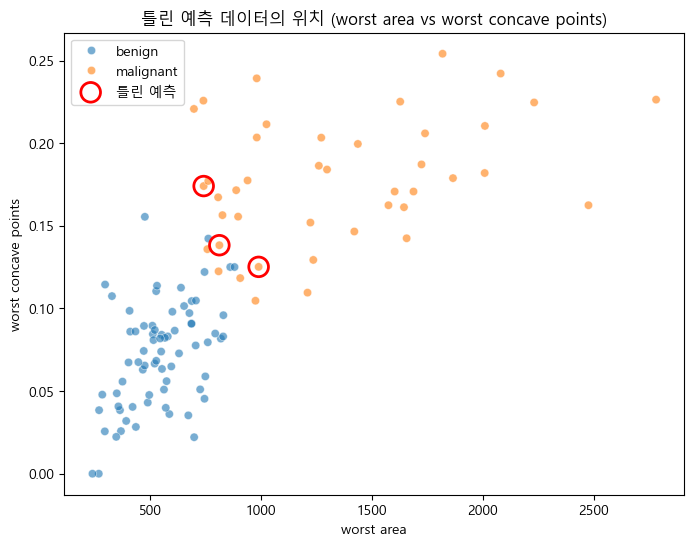

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=result_df,
    x='worst area',
    y='worst concave points',
    hue='y_true_name',
    alpha=0.6
)

if len(wrong_df) > 0:
    plt.scatter(
        wrong_df['worst area'],
        wrong_df['worst concave points'],
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='틀린 예측'
    )
else:
    print('이번 test split에서는 틀린 예측이 없어 별도로 표시할 점이 없습니다.')

plt.title('틀린 예측 데이터의 위치 (worst area vs worst concave points)')
plt.xlabel('worst area')
plt.ylabel('worst concave points')
plt.legend()
plt.show()

In [20]:
# 차원 축소 간단한 예시
scaler_exam_df = pd.DataFrame({
    'house_price': [120000, 115000, 100000, 110000, 119000], # 단위가 크므로 조금만 잘못 예측해도 큰 차이가 남 -> 모델이 여기에 집중
    'owner_age': [24, 38, 65, 42, 52],
    'is_sale_next_month': [0, 1, 0, 1, 1]
})

scaler_exam_df

,house_price,owner_age,is_sale_next_month
0,120000,24,0
1,115000,38,1
2,100000,65,0
3,110000,42,1
4,119000,52,1


In [21]:
scaler_exam_df[['house_price', 'owner_age']].mean()

house_price    112800.0
owner_age          44.2
dtype: float64

In [22]:
scaler_exam_df[['house_price', 'owner_age']].std()

house_price    8167.006796
owner_age        15.368800
dtype: float64

In [23]:
(scaler_exam_df[['house_price', 'owner_age']] - scaler_exam_df[['house_price', 'owner_age']].mean()) \
    / scaler_exam_df[['house_price', 'owner_age']].std()

,house_price,owner_age
0,0.881596,-1.314351
1,0.269377,-0.403415
2,-1.567282,1.353391
3,-0.342843,-0.143147
4,0.759152,0.507522


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components= 2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.fit_transform(X_test_scaled)

print("PCA 변환 후 학습용 데이터 shape:", X_train_pca.shape)
print("PCA 변환 후 평가용 데이터 shape:", X_test_pca.shape)

print("PC1 설명 분산 비율", round(pca.explained_variance_ratio_[0], 3))
print("PC2 설명 분산 비율", round(pca.explained_variance_ratio_[1], 3))
print("PC1 + PC2 설명 분산 비율", round(pca.explained_variance_ratio_.sum(), 3))

PCA 변환 후 학습용 데이터 shape: (455, 2)
PCA 변환 후 평가용 데이터 shape: (114, 2)
PC1 설명 분산 비율 0.399
PC2 설명 분산 비율 0.231
PC1 + PC2 설명 분산 비율 0.63


In [28]:
pca_df = pd.DataFrame({
    "PC1": X_test_pca[:, 0],
    "PC2": X_test_pca[:, 1],
    "y_true" : y_test.values,
    "y_pred" : y_pred,
    "malignant_probability": y_pred_proba
})

pca_df["y_true_name"] = pca_df["y_true"].map({
    0: "benign",
    1: "malignant"
})

pca_df["y_pred_name"] = pca_df["y_pred"].map({
    0: "benign",
    1: "malignant"
})

pca_df["is_correct"] = pca_df["y_true"] == pca_df["y_pred"]

pca_df.head()

,PC1,PC2,y_true,y_pred,malignant_probability,y_true_name,y_pred_name,is_correct
0,-2.697383,-0.257356,0,0,0.001136,benign,benign,True
1,7.030216,-2.250417,1,1,0.999783,malignant,malignant,True
2,0.166845,-0.653768,0,0,0.039927,benign,benign,True
3,0.878545,0.418642,1,1,0.993436,malignant,malignant,True
4,-1.511854,-1.560988,0,0,0.016957,benign,benign,True


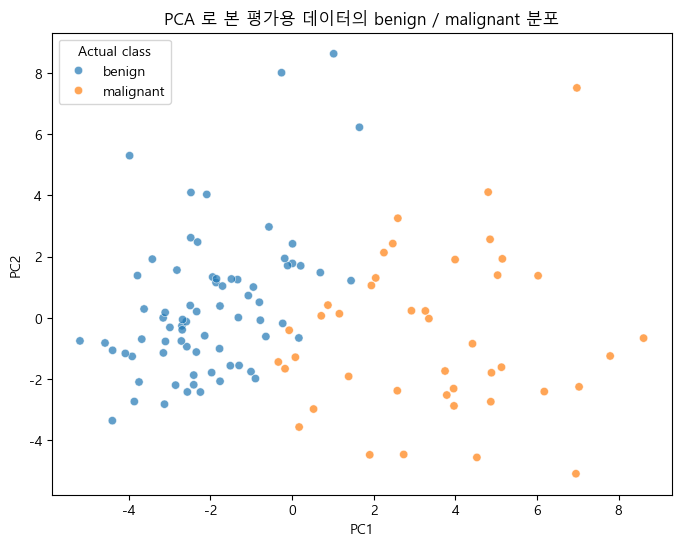

In [29]:
plt.figure(figsize = (8,6))

sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "y_true_name",
    alpha = 0.7
)

plt.title("PCA 로 본 평가용 데이터의 benign / malignant 분포" )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title = "Actual class")
plt.show()

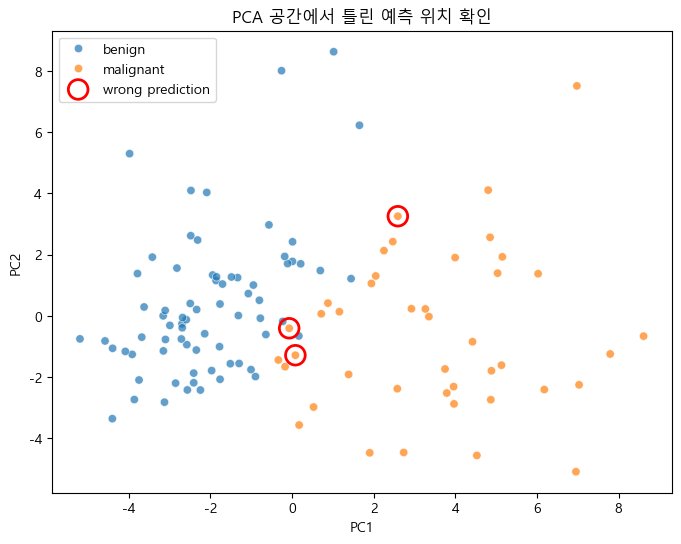

In [30]:
plt.figure(figsize = (8,6))

sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "y_true_name",
    alpha = 0.7
)

wrong_pca_df = pca_df[pca_df["is_correct"] == False]

if len(wrong_pca_df) > 0:
    plt.scatter(
        wrong_pca_df["PC1"],
        wrong_pca_df["PC2"],
        s=200,
        facecolors ="none",
        edgecolors = "red",
        linewidths = 2,
        label = "wrong prediction"
    )
    
plt.title("PCA 공간에서 틀린 예측 위치 확인")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

In [32]:
for threshold in threshold_list:
    print("=" * 70)
    print(f"threshold = {threshold}")
    print("=" * 70)
    
    # malignant 확률이 threshold 이상이면 malignant(1)로 예측합니다.
    # threshold보다 작으면 benign(0)으로 예측합니다.
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # confusion matrix를 계산합니다.
    # 행 = 실제값, 열 = 예측값
    # labels=[0, 1]을 넣어 benign, malignant 순서를 고정합니다.
    cm_threshold = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    )
    
    # confusion matrix를 표 형태로 바꿔서 보여줍니다.
    # 숫자 배열보다 표가 초보자에게 더 이해하기 쉽습니다.
    cm_df = pd.DataFrame(
        cm_threshold,
        index=["Actual benign", "Actual malignant"],
        columns=["Predicted benign", "Predicted malignant"]
    )
    
    print("\n[Confusion Matrix]")
    display(cm_df)

threshold = 0.5

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39


threshold = 0.4

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39


threshold = 0.3

[Confusion Matrix]


...

,Predicted benign,Predicted malignant
Actual benign,70,2
Actual malignant,1,41


threshold = 0.01

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,61,11
Actual malignant,1,41


threshold = 0.001

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,42,30
Actual malignant,0,42


In [33]:
# confusion matrix에서 FN과 FP를 꺼냅니다.
# 이 threshold 실험에서 가장 중요하게 볼 값입니다.
fp = cm_threshold[0, 1]  # 실제 benign인데 malignant로 잘못 예측
fn = cm_threshold[1, 0]  # 실제 malignant인데 benign으로 잘못 예측

print(
    f"[핵심 해석] threshold={threshold} -> "
    f"FN={fn}개(악성을 양성으로 놓침), "
    f"FP={fp}개(양성을 악성으로 잘못 의심)"
)

# classification report를 출력합니다.
# 여기서는 특히 malignant 행의 recall과 precision을 확인합니다.
print("\n[Classification Report]")
print(
    classification_report(
        y_test,
        y_pred_threshold,
        labels=[0, 1],
        target_names=["benign", "malignant"],
        zero_division=0
    )
)

print()

[핵심 해석] threshold=0.001 -> FN=0개(악성을 양성으로 놓침), FP=30개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       1.00      0.58      0.74        72
   malignant       0.58      1.00      0.74        42

    accuracy                           0.74       114
   macro avg       0.79      0.79      0.74       114
weighted avg       0.85      0.74      0.74       114


